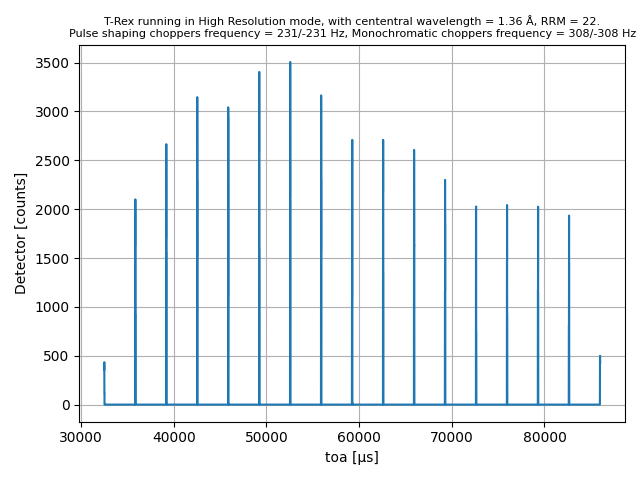

In [1]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.components.source import Source
import plopp as pp
import matplotlib.pylab as plt

central_wavelength = 1.365 * sc.Unit("Å")
# central_wavelength = 0.7150358 * sc.Unit("Å")
# central_wavelength = 6.0 * sc.Unit("Å") # problem here!
mode = "High Resolution"  # Chopper mode
rrm = 22
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess-trex",
    neutrons=100_000,
    optimize_for=trex.choppers,
)
wavelength_requested = trex.calculate_incoming_wavelength()
res = trex.run()

hist_det = res.detectors["Detector"].data.hist(toa=5_000)


fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

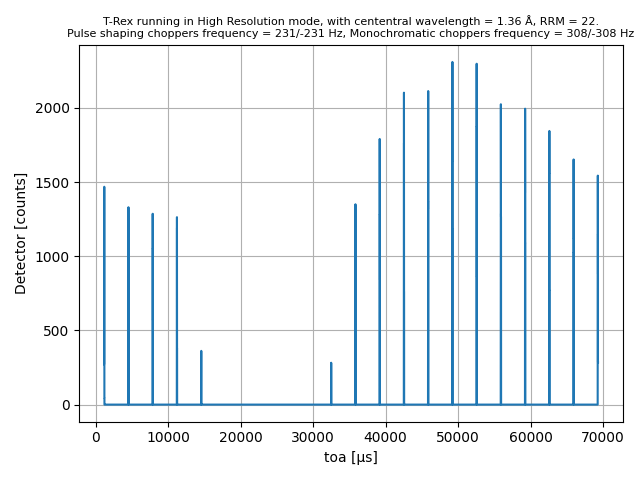

In [6]:
trex.wrap_frame(res)
hist_det = res.detectors["Detector"].data.hist(toa=10_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

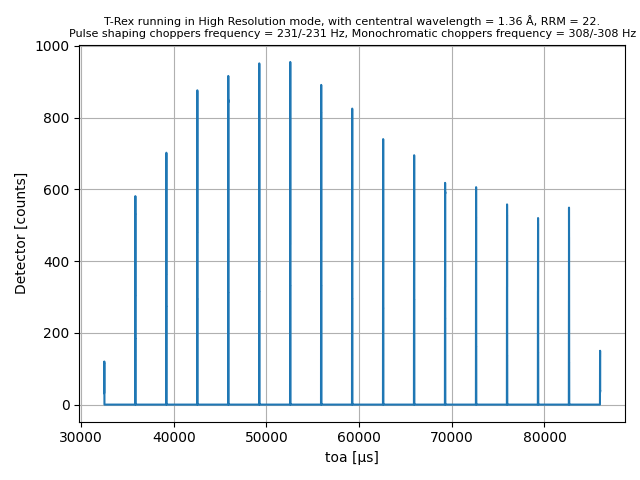

In [7]:
params = trex.unwrap_frame(res, ei_ef_ratio=0.0)
reduced_list = trex.toa_to_energy(res, *params)
hist_det = res.detectors["Detector"].data.hist(toa=20_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

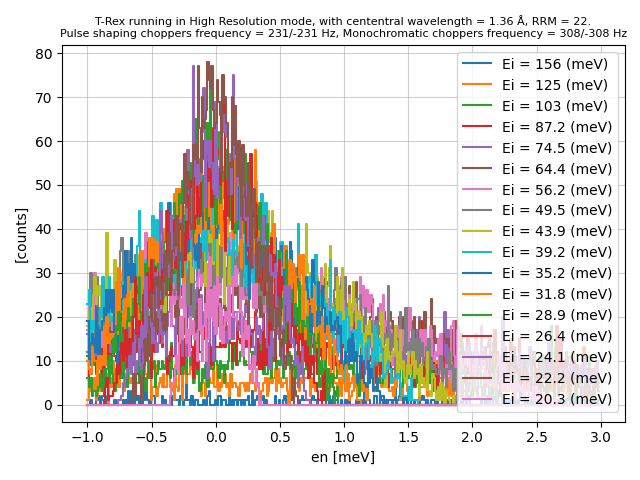

In [9]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -1, 3, 0.0105, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

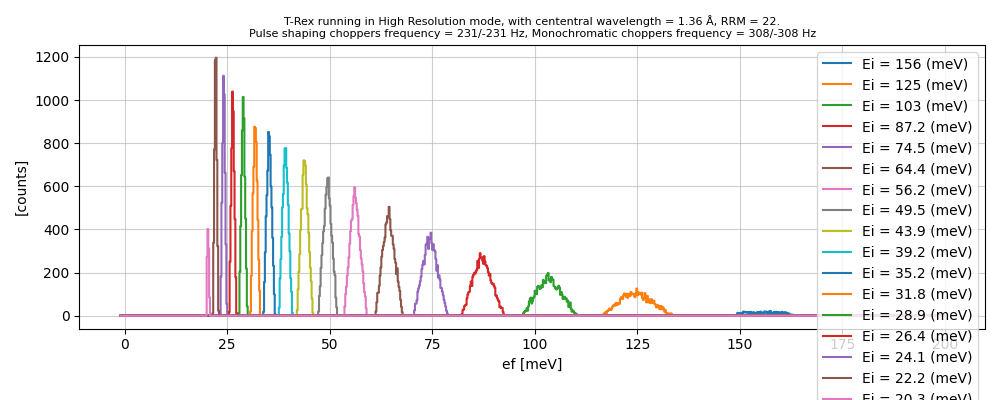

In [10]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", -1, 200, 0.2, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [11]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

delta en FWHM  = [8.6947, 8.4434, 6.4728, 5.0101, 3.998, 3.2339, 2.6845, 2.2439, 1.8798, 1.5906, 1.3515, 1.1429, 0.9663, 0.8418, 0.7461, 0.6433, 0.4288] meV
delta en over ei = [0.056, 0.068, 0.063, 0.057, 0.054, 0.05, 0.048, 0.045, 0.043, 0.041, 0.038, 0.036, 0.033, 0.032, 0.031, 0.029, 0.021]


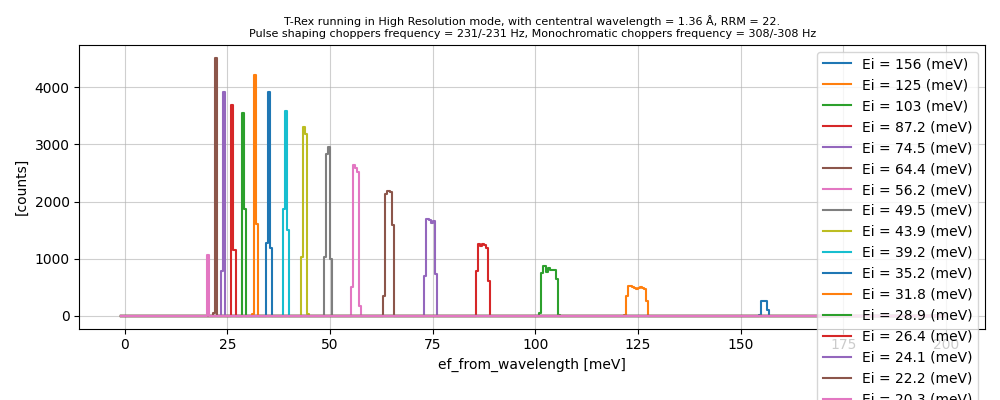

In [12]:
import tof

reduced_list_new = []
for reduced in reduced_list:
    ef_wavelength = tof.utils.wavelength_to_energy(reduced.coords["wavelength"])
    reduced_list_new.append(
        reduced.assign_coords({"ef_from_wavelength": ef_wavelength})
    )

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef_from_wavelength=sc.arange("ef_from_wavelength", -1, 200, 0.5, unit="meV")
    )
    for reduced in reduced_list_new
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [13]:
cen = [
    (da.data * sc.midpoints(da.coords["ef_from_wavelength"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (
            da.data * (sc.midpoints(da.coords["ef_from_wavelength"] - cen[i].data)) ** 2
        ).sum()
        / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
ratio = [round(float(f.data / c.data), 4) for f, c in zip(fwhm, cen)]
print(ratio)

[0.0078, 0.0282, 0.0259, 0.0245, 0.0231, 0.0212, 0.0201, 0.0208, 0.0187, 0.0208, 0.0208, 0.0169, 0.0194, 0.019, 0.0182, 0.0057, 0.0]
